# Fully equivariant EGNN structural autoencoder

This notebook is an executable end-to-end experiment rather than pseudocode. It:

1. trains only on the existing stationary FCC, HCP, and liquid 18-neighbor data;
2. splits complete source frames, preventing particle-level train/validation leakage;
3. extracts periodic 18-neighbor environments directly from the independent FCC and HCP pressure-driven melting trajectories;
4. evaluates both high-density crystalline frames and well-developed liquid frames from each run; and
5. audits O(3) equivariance, neighbor-permutation invariance, reconstruction, noise stability, and the invariant latent space.

The default is the full data/epoch configuration. Set `EGNN_QUICK_RUN=1` before starting the kernel only when you want a short smoke test. The melting trajectories are never used for fitting or early stopping.

In [1]:
from __future__ import annotations

import copy
import os
import random
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Dict, Iterable, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.nn.utils import clip_grad_norm_
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset

plt.style.use("seaborn-v0_8-whitegrid")


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def locate_data_roots() -> Tuple[Path, Path]:
    """Find the stationary training data and the independent melting experiment."""
    cwd = Path.cwd().resolve()
    bases = [cwd, *cwd.parents]
    stationary_candidates = [
        cwd,
        *(base / "lammps/LJ/statistically_independent_samples/statistically_independent_samples"
          for base in bases),
    ]
    melting_candidates = [
        cwd / "melting-crystals",
        cwd.parent.parent / "melting-crystals",
        *(base / "lammps/LJ/melting-crystals" for base in bases),
    ]
    stationary = next(
        (p for p in stationary_candidates
         if all((p / phase / "particle_data_second_shell.npz").exists()
                for phase in ("fcc", "hcp", "liquid"))),
        None,
    )
    melting = next(
        (p for p in melting_candidates
         if (p / "fcc/melting.lammpstrj").exists()
         and (p / "hcp/trajectory.lammpstrj").exists()),
        None,
    )
    if stationary is None or melting is None:
        raise FileNotFoundError(
            "Could not locate both stationary particle_data_second_shell.npz files "
            "and melting-crystals trajectories. Run from the repository or notebook directory."
        )
    return stationary.resolve(), melting.resolve()


@dataclass
class WorkflowConfig:
    seed: int = 17
    fast_run: bool = os.environ.get("EGNN_QUICK_RUN", "0") == "1"
    batch_size: int = 64
    max_train_samples_per_phase: int = 1024
    max_validation_samples_per_phase: int = 256
    max_test_samples_per_phase: int = 256
    epochs: int = 3
    patience: int = 3
    evaluation_frames_per_regime: int = 2
    centers_per_evaluation_frame: int = 32

    def __post_init__(self):
        if not self.fast_run:
            self.batch_size = 128
            self.max_train_samples_per_phase = 12000
            self.max_validation_samples_per_phase = 2500
            self.max_test_samples_per_phase = 2500
            self.epochs = 30
            self.patience = 6
            self.evaluation_frames_per_regime = 8
            self.centers_per_evaluation_frame = 128


WORKFLOW = WorkflowConfig()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STATIONARY_ROOT, MELTING_ROOT = locate_data_roots()
set_seed(WORKFLOW.seed)

print("Device:", DEVICE)
print("Mode:", "quick end-to-end check" if WORKFLOW.fast_run else "full experiment")
print("Stationary training data:", STATIONARY_ROOT)
print("Unseen melting evaluation data:", MELTING_ROOT)
print("Set EGNN_QUICK_RUN=1 before starting the kernel only for a short smoke test.")


Device: cuda
Mode: full experiment
Stationary training data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/statistically_independent_samples/statistically_independent_samples
Unseen melting evaluation data: /home/jakob/Masterabeit/autoencode_statmech/lammps/LJ/melting-crystals
Set EGNN_QUICK_RUN=1 before starting the kernel only for a short smoke test.


In [2]:
PHASES = ("fcc", "hcp", "liquid")
PHASE_TO_ID = {phase: i for i, phase in enumerate(PHASES)}
SECOND_SHELL_FILE = "particle_data_second_shell.npz"


def _frame_partition(frame_indices: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    """Split by complete MD frames to prevent particle-level leakage."""
    frames = rng.permutation(np.unique(frame_indices))
    if len(frames) < 5:
        raise ValueError("At least five independent frames are required per phase.")
    n_test = max(1, round(0.15 * len(frames)))
    n_val = max(1, round(0.15 * len(frames)))
    split = np.full(len(frame_indices), "train", dtype="<U5")
    split[np.isin(frame_indices, frames[:n_test])] = "test"
    split[np.isin(frame_indices, frames[n_test:n_test + n_val])] = "val"
    return split


def _sample_indices(indices: np.ndarray, maximum: int, rng: np.random.Generator) -> np.ndarray:
    if len(indices) <= maximum:
        return np.sort(indices)
    return np.sort(rng.choice(indices, size=maximum, replace=False))


def prepare_stationary_training_data(
    root: Path = STATIONARY_ROOT,
    workflow: WorkflowConfig = WORKFLOW,
) -> Dict[str, object]:
    """Load 18-neighbor environments from the non-melting simulations.

    Only these stationary trajectories are used for fitting. The pressure-driven
    melting trajectories are reserved as a genuinely unseen evaluation set.
    """
    rng = np.random.default_rng(workflow.seed)
    parts = {name: [] for name in ("train", "val", "test")}
    label_parts = {name: [] for name in parts}
    summary = []

    for phase in PHASES:
        path = root / phase / SECOND_SHELL_FILE
        with np.load(path, allow_pickle=False) as npz:
            vectors = np.asarray(npz["vec_dist"], dtype=np.float32)
            frames = np.asarray(npz["frame_indices"], dtype=np.int64)
            stored_nn = int(np.asarray(npz["nn"]).item())
        if vectors.shape[1:] != (18, 3) or stored_nn != 18:
            raise ValueError(f"{path} is not an 18-neighbor data set: {vectors.shape}, nn={stored_nn}")
        if not np.isfinite(vectors).all():
            raise ValueError(f"Non-finite coordinates in {path}")

        split = _frame_partition(frames, rng)
        limits = {
            "train": workflow.max_train_samples_per_phase,
            "val": workflow.max_validation_samples_per_phase,
            "test": workflow.max_test_samples_per_phase,
        }
        row = {"phase": phase, "source": path.name, "stored_samples": len(vectors)}
        for name, limit in limits.items():
            chosen = _sample_indices(np.flatnonzero(split == name), limit, rng)
            parts[name].append(vectors[chosen])
            label_parts[name].append(np.full(len(chosen), PHASE_TO_ID[phase], dtype=np.int64))
            row[f"{name}_samples"] = len(chosen)
            row[f"{name}_frames"] = np.unique(frames[chosen]).size
        summary.append(row)

    coordinates = {name: np.concatenate(value) for name, value in parts.items()}
    labels = {name: np.concatenate(value) for name, value in label_parts.items()}
    coordinate_scale = float(np.median(np.linalg.norm(coordinates["train"], axis=-1)))
    coordinates = {
        name: (value / coordinate_scale).astype(np.float32, copy=False)
        for name, value in coordinates.items()
    }
    return {
        "coordinates": coordinates,
        "labels": labels,
        "coordinate_scale": coordinate_scale,
        "summary": pd.DataFrame(summary),
    }


def make_loaders(dataset: Dict[str, object], workflow: WorkflowConfig = WORKFLOW):
    loaders = {}
    for offset, name in enumerate(("train", "val", "test")):
        generator = torch.Generator().manual_seed(workflow.seed + offset)
        tensors = TensorDataset(
            torch.from_numpy(dataset["coordinates"][name]),
            torch.from_numpy(dataset["labels"][name]),
        )
        loaders[name] = DataLoader(
            tensors,
            batch_size=workflow.batch_size,
            shuffle=name == "train",
            generator=generator if name == "train" else None,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )
    return loaders


In [3]:
MELTING_RUNS = {
    "fcc": {
        "trajectory": MELTING_ROOT / "fcc/melting.lammpstrj",
        "observables": MELTING_ROOT / "fcc/melting_observables.dat",
    },
    "hcp": {
        "trajectory": MELTING_ROOT / "hcp/trajectory.lammpstrj",
        "observables": MELTING_ROOT / "hcp/melting_observables.dat",
    },
}
OBSERVABLE_COLUMNS = ["timestep", "temperature", "pressure", "potential", "volume", "density", "Q6"]
LIQUID_RELAXATION_STEPS = 50_000  # end of the frame-resolved transition window in the melting analysis


def read_melting_observables(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, comment="#", sep=r"\s+", names=OBSERVABLE_COLUMNS, engine="python")


def _evenly_spaced_rows(table: pd.DataFrame, count: int) -> pd.DataFrame:
    table = table.sort_values("timestep").drop_duplicates("timestep")
    if len(table) < count:
        raise ValueError(f"Only {len(table)} eligible frames, but {count} were requested.")
    positions = np.unique(np.rint(np.linspace(0, len(table) - 1, count)).astype(int))
    return table.iloc[positions]


def select_melting_evaluation_frames(
    runs=MELTING_RUNS,
    frames_per_regime: int = WORKFLOW.evaluation_frames_per_regime,
) -> pd.DataFrame:
    """Select high-density crystals and well-developed liquids from both runs.

    The transition is the steepest drop of a rolling-median Q6 trace, matching the
    melting-analysis notebook. Dense crystals come from the upper density quartile
    at least 50k steps before that event. Liquid evaluation begins only after the
    notebook's complete +50k frame-resolved transition window and additionally
    requires membership in the bottom 15% of the run's robust Q6 range. This avoids
    treating the first classifier-collapse frame as a mature liquid reference.
    """
    selected = []
    for phase, paths in runs.items():
        obs = read_melting_observables(paths["observables"])
        smooth_q6 = obs["Q6"].rolling(21, center=True, min_periods=3).median()
        transition_step = int(obs.loc[smooth_q6.diff().idxmin(), "timestep"])
        q_low, q_high = obs["Q6"].quantile([0.05, 0.95])

        pre = obs[
            (obs.timestep >= 200_000)
            & (obs.timestep <= transition_step - 50_000)
            & (obs.Q6 >= q_high - 0.20 * (q_high - q_low))
        ]
        dense = pre[pre.density >= pre.density.quantile(0.75)]
        if len(dense) < frames_per_regime:
            dense = pre.nlargest(max(frames_per_regime, 4 * frames_per_regime), "density")

        post = obs[
            (obs.timestep >= transition_step + LIQUID_RELAXATION_STEPS)
            & (obs.Q6 <= q_low + 0.15 * (q_high - q_low))
        ]
        dense_choice = _evenly_spaced_rows(dense, frames_per_regime)
        liquid_choice = _evenly_spaced_rows(post, frames_per_regime)
        for regime, choice in (("dense_crystal", dense_choice), ("liquid", liquid_choice)):
            block = choice.copy()
            block["phase_origin"] = phase
            block["regime"] = regime
            block["transition_step"] = transition_step
            block["liquid_reference_start"] = transition_step + LIQUID_RELAXATION_STEPS
            selected.append(block)
    columns = ["phase_origin", "regime", "timestep", "density", "Q6", "temperature", "pressure", "transition_step", "liquid_reference_start"]
    return pd.concat(selected, ignore_index=True)[columns].sort_values(["phase_origin", "regime", "timestep"])


def iter_selected_lammps_frames(path: Path, wanted_timesteps: Sequence[int]):
    """Stream selected orthorhombic LAMMPS frames with x/y/z or xs/ys/zs columns."""
    wanted = {int(step) for step in wanted_timesteps}
    found = set()
    with path.open("r") as handle:
        while True:
            marker = handle.readline()
            if not marker:
                break
            if not marker.startswith("ITEM: TIMESTEP"):
                raise ValueError(f"Malformed trajectory {path}: {marker.strip()}")
            timestep = int(handle.readline())
            if not handle.readline().startswith("ITEM: NUMBER OF ATOMS"):
                raise ValueError(f"Missing atom count in {path} at step {timestep}")
            n_atoms = int(handle.readline())
            box_header = handle.readline()
            if not box_header.startswith("ITEM: BOX BOUNDS"):
                raise ValueError(f"Missing box bounds in {path} at step {timestep}")
            bounds = np.array(
                [[float(value) for value in handle.readline().split()[:2]] for _ in range(3)],
                dtype=np.float64,
            )
            atom_header = handle.readline().split()[2:]
            if timestep not in wanted:
                for _ in range(n_atoms):
                    handle.readline()
                continue

            values = np.empty((n_atoms, len(atom_header)), dtype=np.float64)
            for atom in range(n_atoms):
                row = np.fromstring(handle.readline(), sep=" ")
                if len(row) != len(atom_header):
                    raise ValueError(f"Bad atom row in {path} at step {timestep}")
                values[atom] = row
            columns = {name: i for i, name in enumerate(atom_header)}
            order = np.argsort(values[:, columns["id"]].astype(np.int64))
            values = values[order]
            lengths = bounds[:, 1] - bounds[:, 0]
            if all(name in columns for name in ("x", "y", "z")):
                positions = values[:, [columns["x"], columns["y"], columns["z"]]]
            elif all(name in columns for name in ("xs", "ys", "zs")):
                fractional = values[:, [columns["xs"], columns["ys"], columns["zs"]]]
                positions = bounds[:, 0] + fractional * lengths
            else:
                raise ValueError(f"No supported coordinate columns in {path}: {atom_header}")
            atom_ids = values[:, columns["id"]].astype(np.int64)
            found.add(timestep)
            yield timestep, positions, lengths, atom_ids
            if found == wanted:
                break
    missing = wanted - found
    if missing:
        raise KeyError(f"Trajectory {path} is missing selected timesteps: {sorted(missing)}")


def extract_periodic_neighborhoods(
    positions: np.ndarray,
    box_lengths: np.ndarray,
    atom_ids: np.ndarray,
    n_neighbors: int,
    n_centers: int,
    rng: np.random.Generator,
):
    n_centers = min(n_centers, len(positions))
    centers = np.sort(rng.choice(len(positions), size=n_centers, replace=False))
    displacement = positions[None, :, :] - positions[centers, None, :]
    displacement -= box_lengths * np.rint(displacement / box_lengths)
    squared_distance = np.einsum("cni,cni->cn", displacement, displacement)
    squared_distance[np.arange(n_centers), centers] = np.inf
    neighbors = np.argpartition(squared_distance, n_neighbors - 1, axis=1)[:, :n_neighbors]
    local_order = np.argsort(np.take_along_axis(squared_distance, neighbors, axis=1), axis=1)
    neighbors = np.take_along_axis(neighbors, local_order, axis=1)
    vectors = np.take_along_axis(displacement, neighbors[:, :, None], axis=1)
    return vectors.astype(np.float32), atom_ids[centers]


def build_unseen_melting_dataset(
    coordinate_scale: float,
    workflow: WorkflowConfig = WORKFLOW,
):
    selection = select_melting_evaluation_frames(frames_per_regime=workflow.evaluation_frames_per_regime)
    rng = np.random.default_rng(workflow.seed + 10_000)
    coordinate_parts, metadata_parts = [], []
    for phase, paths in MELTING_RUNS.items():
        phase_selection = selection[selection.phase_origin == phase]
        lookup = phase_selection.set_index("timestep")
        for timestep, positions, lengths, atom_ids in iter_selected_lammps_frames(
            paths["trajectory"], phase_selection.timestep
        ):
            vectors, center_ids = extract_periodic_neighborhoods(
                positions, lengths, atom_ids, 18, workflow.centers_per_evaluation_frame, rng
            )
            coordinate_parts.append(vectors / coordinate_scale)
            row = lookup.loc[timestep]
            metadata_parts.append(pd.DataFrame({
                "phase_origin": phase,
                "regime": row.regime,
                "timestep": timestep,
                "density": float(row.density),
                "Q6": float(row.Q6),
                "center_atom_id": center_ids,
            }))
    return {
        "coordinates": np.concatenate(coordinate_parts).astype(np.float32),
        "metadata": pd.concat(metadata_parts, ignore_index=True),
        "selection": selection.reset_index(drop=True),
        "coordinate_scale": coordinate_scale,
    }


## Model and symmetry-aware objectives

The invariant branch is the structural order parameter. Vector and traceless rank-2 branches carry pose information required by the equivariant set decoder.

In [4]:
"""EGNN structural autoencoder with invariant + equivariant latent branches.

Research goal
-------------
Learn a compact structural order parameter directly from local point-cloud geometry,
while enforcing Euclidean / O(3) symmetry and permutation symmetry by construction.

The model accepts N local neighbor coordinates relative to a distinguished center.
It encodes them with EGNN blocks, splits the latent into

    z_structure : invariant scalars
    z_vector    : O(3)-equivariant polar vectors
    z_tensor    : O(3)-equivariant even rank-2 traceless tensors

and reconstructs the neighbor set with an explicitly O(3)-equivariant set decoder.

Important limitation
--------------------
A perfectly high-symmetry environment (e.g. ideal FCC) does not define a unique
vector frame. Any permutation-equivariant vector pooling can therefore vanish on
such an environment. This is a representation-theoretic issue, not an optimizer
bug. The vector/tensor decoder below is best viewed as a practical model for noisy
MD environments. For exact crystal prototypes, consider (i) reconstructing only
invariant geometry, (ii) retaining node-level equivariant memory, or (iii) moving
to higher-order irreps (e.g. e3nn with l >= 4 for cubic order).

Suggested ablations
-------------------
Run every objective with the same data splits and vary one factor at a time:

A0  Naive baseline: no EGNN coordinate updates, mean-pool scalar node features.
A1  + Full neighbor-neighbor graph (vs. center-star graph only).
A2  + EGNN coordinate updates.
A3  + Smooth distance RBF embedding (vs. raw squared distance only).
A4  + Attention pooling for z_structure (vs. mean pooling).
A5  + Equivariant vector latent.
A6  + Equivariant rank-2 tensor latent.
A7  + Tensor-generated decoder basis T v and T^2 v.
A8  + Noise-consistency loss on z_structure.
A9  + VICReg-style variance/covariance anti-collapse regularization.
A10 + Sinkhorn set reconstruction (vs. Chamfer).
A11 Vary latent dimensionality: 2, 4, 8, 16, 32.
A12 Vary noise amplitude and whether sigma is fixed or sampled.
A13 Vary depth / hidden width at fixed latent budget.
A14 Remove the equivariant branch and reconstruct only invariant geometry.

The most scientifically informative comparisons are usually not the largest model
vs. the smallest model, but the point at which adding a symmetry prior first makes
an otherwise failing representation work.
"""

from __future__ import annotations

from dataclasses import dataclass, replace
from typing import Dict, Optional, Tuple

import math
import torch
from torch import nn
import torch.nn.functional as F

Tensor = torch.Tensor


@dataclass
class ModelConfig:
    num_neighbors: int = 18
    node_feature_dim: int = 0
    hidden_dim: int = 128
    message_dim: int = 128
    num_layers: int = 4
    struct_dim: int = 8
    num_vector_latents: int = 3
    num_tensor_latents: int = 2
    num_rbf: int = 16
    rbf_max_distance: float = 3.0
    use_rbf: bool = True
    coordinate_updates: bool = True
    attention_pooling: bool = True
    include_center_node: bool = True
    use_tensor_basis: bool = True
    tensor_basis_order: int = 2   # 0: vectors only, 1: +T v, 2: +T^2 v
    decoder_hidden_dim: int = 256
    dropout: float = 0.0
    residual: bool = True
    normalize_messages: bool = True
    normalize_pose_vectors: bool = False
    normalize_pose_tensors: bool = False


class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        out_dim: int,
        hidden_dim: int,
        depth: int = 2,
        dropout: float = 0.0,
        final_activation: bool = False,
    ):
        super().__init__()
        dims = [in_dim] + [hidden_dim] * max(depth - 1, 0) + [out_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            is_last = i == len(dims) - 2
            if (not is_last) or final_activation:
                layers.append(nn.SiLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)


class GaussianRBF(nn.Module):
    """Smooth scalar distance encoding; no angular/spherical-harmonic features."""

    def __init__(self, num_rbf: int, max_distance: float):
        super().__init__()
        centers = torch.linspace(0.0, max_distance, num_rbf)
        self.register_buffer("centers", centers)
        if num_rbf > 1:
            delta = centers[1] - centers[0]
        else:
            delta = torch.tensor(max_distance)
        self.gamma = float(1.0 / (delta.item() ** 2 + 1e-12))

    def forward(self, d: Tensor) -> Tensor:
        # d: [..., 1]
        return torch.exp(-self.gamma * (d - self.centers) ** 2)


class EGNNBlock(nn.Module):
    """E(n)/O(3)-equivariant message-passing block.

    Invariant node features h are updated from invariant distances/messages.
    Coordinates x are optionally updated by scalar-weighted relative vectors.
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        edge_geom_dim = cfg.num_rbf if cfg.use_rbf else 1
        if cfg.use_rbf:
            self.rbf = GaussianRBF(cfg.num_rbf, cfg.rbf_max_distance)
        else:
            self.rbf = None

        self.edge_mlp = MLP(
            2 * cfg.hidden_dim + edge_geom_dim,
            cfg.message_dim,
            cfg.hidden_dim,
            depth=3,
            dropout=cfg.dropout,
        )
        self.edge_gate = MLP(
            cfg.message_dim,
            1,
            cfg.hidden_dim,
            depth=2,
            dropout=cfg.dropout,
        )
        self.coord_mlp = MLP(
            cfg.message_dim,
            1,
            cfg.hidden_dim,
            depth=2,
            dropout=cfg.dropout,
        )
        self.node_mlp = MLP(
            cfg.hidden_dim + cfg.message_dim,
            cfg.hidden_dim,
            cfg.hidden_dim,
            depth=3,
            dropout=cfg.dropout,
        )
        self.norm = nn.LayerNorm(cfg.hidden_dim)

    def forward(
        self,
        h: Tensor,          # [B, M, H]
        x: Tensor,          # [B, M, 3]
        node_mask: Tensor,  # [B, M] bool
        edge_mask: Optional[Tensor] = None,  # [B, M, M] bool
        center_index: int = 0,
    ) -> Tuple[Tensor, Tensor]:
        B, M, _ = x.shape

        xi = x[:, :, None, :]                     # [B,M,1,3]
        xj = x[:, None, :, :]                     # [B,1,M,3]
        diff = xi - xj                            # [B,M,M,3]
        d2 = (diff * diff).sum(-1, keepdim=True)  # [B,M,M,1]
        d = torch.sqrt(d2 + 1e-12)

        hi = h[:, :, None, :].expand(-1, -1, M, -1)
        hj = h[:, None, :, :].expand(-1, M, -1, -1)
        geom = self.rbf(d) if self.rbf is not None else d2
        edge_in = torch.cat([hi, hj, geom], dim=-1)
        msg = self.edge_mlp(edge_in)
        msg = msg * torch.sigmoid(self.edge_gate(msg))

        valid = node_mask[:, :, None] & node_mask[:, None, :]
        eye = torch.eye(M, dtype=torch.bool, device=x.device)[None]
        valid = valid & (~eye)
        if edge_mask is not None:
            valid = valid & edge_mask
        valid_f = valid.unsqueeze(-1).to(msg.dtype)
        msg = msg * valid_f

        agg = msg.sum(dim=2)
        if self.cfg.normalize_messages:
            degree = valid.sum(dim=2, keepdim=True).clamp_min(1).to(msg.dtype)
            agg = agg / degree

        h_update = self.node_mlp(torch.cat([h, agg], dim=-1))
        h_new = h + h_update if self.cfg.residual else h_update
        h_new = self.norm(h_new)
        h_new = h_new * node_mask.unsqueeze(-1).to(h_new.dtype)

        if self.cfg.coordinate_updates:
            coeff = self.coord_mlp(msg) * valid_f
            # Stabilize coordinate updates. Scalar coeff keeps O(3)-equivariance.
            coeff = 0.1 * torch.tanh(coeff)
            dx = (diff * coeff).sum(dim=2)
            if self.cfg.normalize_messages:
                degree = valid.sum(dim=2, keepdim=True).clamp_min(1).to(dx.dtype)
                dx = dx / degree
            x_new = x + dx
        else:
            x_new = x

        # Work in the center-relative frame after every block.
        center = x_new[:, center_index:center_index + 1, :]
        x_new = (x_new - center) * node_mask.unsqueeze(-1).to(x_new.dtype)
        return h_new, x_new


class InvariantSetPool(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        self.value = MLP(cfg.hidden_dim, cfg.hidden_dim, cfg.hidden_dim, depth=2)
        if cfg.attention_pooling:
            self.logit = MLP(cfg.hidden_dim, 1, cfg.hidden_dim, depth=2)
        else:
            self.logit = None

    def forward(self, h: Tensor, mask: Tensor) -> Tensor:
        v = self.value(h)
        m = mask.unsqueeze(-1)
        if self.logit is None:
            denom = mask.sum(dim=1, keepdim=True).clamp_min(1).to(v.dtype)
            return (v * m.to(v.dtype)).sum(dim=1) / denom

        logits = self.logit(h).squeeze(-1)
        logits = logits.masked_fill(~mask, -1e9)
        w = torch.softmax(logits, dim=1).unsqueeze(-1)
        return (w * v).sum(dim=1)


class EquivariantLatentPool(nn.Module):
    """Pool polar vectors and even rank-2 traceless tensors.

    Vector channels transform as v -> R v.
    Tensor channels transform as T -> R T R^T.
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        Kv = cfg.num_vector_latents
        Kt = cfg.num_tensor_latents
        self.vector_logits = MLP(cfg.hidden_dim, Kv, cfg.hidden_dim, depth=2) if Kv > 0 else None
        self.tensor_logits = MLP(cfg.hidden_dim, Kt, cfg.hidden_dim, depth=2) if Kt > 0 else None

    @staticmethod
    def _masked_softmax(logits: Tensor, mask: Tensor, dim: int) -> Tensor:
        logits = logits.masked_fill(~mask.unsqueeze(-1), -1e9)
        return torch.softmax(logits, dim=dim)

    def forward(self, h: Tensor, x: Tensor, mask: Tensor) -> Dict[str, Tensor]:
        out: Dict[str, Tensor] = {}

        if self.vector_logits is not None:
            wv = self._masked_softmax(self.vector_logits(h), mask, dim=1)  # [B,M,Kv]
            z_vec = torch.einsum("bmk,bmd->bkd", wv, x)                   # [B,Kv,3]
            if self.cfg.normalize_pose_vectors:
                z_vec = z_vec / (z_vec.norm(dim=-1, keepdim=True) + 1e-8)
            out["vector"] = z_vec

        if self.tensor_logits is not None:
            wt = self._masked_softmax(self.tensor_logits(h), mask, dim=1)  # [B,M,Kt]
            outer = x[..., :, None] * x[..., None, :]                       # [B,M,3,3]
            r2 = (x * x).sum(-1)                                            # [B,M]
            I = torch.eye(3, device=x.device, dtype=x.dtype)
            q = outer - (r2[..., None, None] / 3.0) * I                     # traceless even tensor
            z_t = torch.einsum("bmk,bmij->bkij", wt, q)                    # [B,Kt,3,3]
            if self.cfg.normalize_pose_tensors:
                z_t = z_t / (z_t.square().sum(dim=(-1, -2), keepdim=True).sqrt() + 1e-8)
            out["tensor"] = z_t

        return out


class EquivariantSetDecoder(nn.Module):
    """Decode an unordered point set from invariant coefficients + equivariant bases.

    If b_a are polar-vector basis channels and c_{ia}(z_structure) are invariant
    coefficients, then r_i = sum_a c_{ia} b_a is exactly O(3)-equivariant.
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        Kv = cfg.num_vector_latents
        Kt = cfg.num_tensor_latents
        if Kv <= 0:
            raise ValueError("Coordinate reconstruction requires at least one vector latent channel.")

        basis_count = Kv
        if cfg.use_tensor_basis and Kt > 0 and cfg.tensor_basis_order >= 1:
            basis_count += Kv * Kt
        if cfg.use_tensor_basis and Kt > 0 and cfg.tensor_basis_order >= 2:
            basis_count += Kv * Kt

        self.basis_count = basis_count
        self.coeff_net = MLP(
            cfg.struct_dim,
            cfg.num_neighbors * basis_count,
            cfg.decoder_hidden_dim,
            depth=4,
            dropout=cfg.dropout,
        )

    def _build_basis(self, z_vec: Tensor, z_tensor: Optional[Tensor]) -> Tensor:
        # z_vec: [B,Kv,3]
        basis = [z_vec]
        if self.cfg.use_tensor_basis and z_tensor is not None and self.cfg.tensor_basis_order >= 1:
            # Tv: [B,Kt,Kv,3]
            Tv = torch.einsum("btij,bvj->btvi", z_tensor, z_vec)
            basis.append(Tv.flatten(1, 2))

            if self.cfg.tensor_basis_order >= 2:
                T2v = torch.einsum("btij,btvj->btvi", z_tensor, Tv)
                basis.append(T2v.flatten(1, 2))

        return torch.cat(basis, dim=1)  # [B,Kbasis,3]

    def forward(self, z_struct: Tensor, eq: Dict[str, Tensor]) -> Tensor:
        z_vec = eq["vector"]
        z_tensor = eq.get("tensor", None)
        basis = self._build_basis(z_vec, z_tensor)
        B = z_struct.shape[0]
        coeff = self.coeff_net(z_struct).view(B, self.cfg.num_neighbors, self.basis_count)
        # Invariant coefficients x equivariant basis => equivariant coordinates.
        x_hat = torch.einsum("bna,bad->bnd", coeff, basis)
        return x_hat


class StructuralEGNNAutoencoder(nn.Module):
    """Permutation-aware, O(3)-equivariant autoencoder with split latent.

    Input
    -----
    x_neighbors : [B, N, 3]
        Neighbor coordinates relative to the central particle. If absolute
        coordinates are supplied, pass center separately and subtract it first.
    node_features : optional [B, N, F]
        Rotation-invariant particle attributes (species embedding inputs, etc.).
    mask : optional [B, N]
        True for valid neighbors. With fixed 18-NN neighborhoods this can be all True.
    graph_mode : "full" or "star"
        "full" includes all neighbor-neighbor edges plus center edges.
        "star" includes only center<->neighbor edges and is a useful ablation.

    Outputs
    -------
    reconstruction : [B, N, 3]
    z_structure    : [B, struct_dim] invariant under O(3)
    z_vector       : [B, Kv, 3] transforms as R v
    z_tensor       : [B, Kt, 3, 3] transforms as R T R^T

    Exact symmetry target
    ---------------------
    For any R in O(3):
        z_structure(RX) = z_structure(X)
        z_vector(RX)    = R z_vector(X)
        z_tensor(RX)    = R z_tensor(X) R^T
        decode(encode(RX)) = R decode(encode(X))

    Recommended primary ablations
    -----------------------------
    1. graph_mode: star -> full
    2. coordinate_updates: False -> True
    3. use_rbf: False -> True
    4. attention_pooling: False -> True
    5. num_tensor_latents: 0 -> >0
    6. tensor_basis_order: 0 -> 1 -> 2
    7. struct_dim: 2,4,8,16,32
    8. remove/add latent noise consistency
    9. Chamfer vs Sinkhorn set reconstruction
    10. prototype-denoising vs MD self-denoising objective
    """

    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg

        # Initial features: constant 1, center flag, optional invariant attributes.
        input_dim = 2 + cfg.node_feature_dim
        self.node_embed = MLP(input_dim, cfg.hidden_dim, cfg.hidden_dim, depth=2)
        self.blocks = nn.ModuleList([EGNNBlock(cfg) for _ in range(cfg.num_layers)])
        self.struct_pool = InvariantSetPool(cfg)
        self.struct_head = MLP(cfg.hidden_dim, cfg.struct_dim, cfg.hidden_dim, depth=3)
        self.eq_pool = EquivariantLatentPool(cfg)
        self.decoder = EquivariantSetDecoder(cfg)

    def _prepare_nodes(
        self,
        x_neighbors: Tensor,
        node_features: Optional[Tensor],
        mask: Optional[Tensor],
    ) -> Tuple[Tensor, Tensor, Tensor]:
        B, N, D = x_neighbors.shape
        if N != self.cfg.num_neighbors or D != 3:
            raise ValueError(f"Expected [B,{self.cfg.num_neighbors},3], got {tuple(x_neighbors.shape)}")

        if mask is None:
            mask = torch.ones(B, N, dtype=torch.bool, device=x_neighbors.device)

        if self.cfg.include_center_node:
            center = torch.zeros(B, 1, 3, device=x_neighbors.device, dtype=x_neighbors.dtype)
            x = torch.cat([center, x_neighbors], dim=1)
            full_mask = torch.cat([
                torch.ones(B, 1, dtype=torch.bool, device=x_neighbors.device),
                mask,
            ], dim=1)

            ones = torch.ones(B, N + 1, 1, device=x.device, dtype=x.dtype)
            center_flag = torch.zeros_like(ones)
            center_flag[:, 0, 0] = 1.0

            if self.cfg.node_feature_dim > 0:
                if node_features is None:
                    raise ValueError("node_features are required by config")
                zero_center = torch.zeros(B, 1, self.cfg.node_feature_dim, device=x.device, dtype=x.dtype)
                nf = torch.cat([zero_center, node_features], dim=1)
                init = torch.cat([ones, center_flag, nf], dim=-1)
            else:
                init = torch.cat([ones, center_flag], dim=-1)
        else:
            x = x_neighbors
            full_mask = mask
            ones = torch.ones(B, N, 1, device=x.device, dtype=x.dtype)
            center_flag = torch.zeros_like(ones)
            if self.cfg.node_feature_dim > 0:
                if node_features is None:
                    raise ValueError("node_features are required by config")
                init = torch.cat([ones, center_flag, node_features], dim=-1)
            else:
                init = torch.cat([ones, center_flag], dim=-1)

        h = self.node_embed(init)
        return h, x, full_mask

    def _edge_mask(self, full_mask: Tensor, graph_mode: str) -> Optional[Tensor]:
        if graph_mode == "full":
            return None
        if graph_mode != "star":
            raise ValueError("graph_mode must be 'full' or 'star'")
        M = full_mask.shape[1]
        em = torch.zeros(full_mask.shape[0], M, M, dtype=torch.bool, device=full_mask.device)
        em[:, 0, 1:] = True
        em[:, 1:, 0] = True
        return em

    def encode(
        self,
        x_neighbors: Tensor,
        node_features: Optional[Tensor] = None,
        mask: Optional[Tensor] = None,
        graph_mode: str = "full",
    ) -> Dict[str, Tensor]:
        h, x, full_mask = self._prepare_nodes(x_neighbors, node_features, mask)
        em = self._edge_mask(full_mask, graph_mode)

        for block in self.blocks:
            h, x = block(h, x, full_mask, edge_mask=em, center_index=0)

        # Exclude the distinguished center from latent pooling.
        if self.cfg.include_center_node:
            h_pool = h[:, 1:]
            x_pool = x[:, 1:]
            mask_pool = full_mask[:, 1:]
        else:
            h_pool, x_pool, mask_pool = h, x, full_mask

        pooled = self.struct_pool(h_pool, mask_pool)
        z_struct = self.struct_head(pooled)
        eq = self.eq_pool(h_pool, x_pool, mask_pool)

        return {
            "z_structure": z_struct,
            "z_vector": eq.get("vector", None),
            "z_tensor": eq.get("tensor", None),
            "eq": eq,
            "node_features": h_pool,
            "node_coords": x_pool,
        }

    def decode(self, latent: Dict[str, Tensor]) -> Tensor:
        return self.decoder(latent["z_structure"], latent["eq"])

    def forward(
        self,
        x_neighbors: Tensor,
        node_features: Optional[Tensor] = None,
        mask: Optional[Tensor] = None,
        graph_mode: str = "full",
    ) -> Dict[str, Tensor]:
        latent = self.encode(x_neighbors, node_features=node_features, mask=mask, graph_mode=graph_mode)
        reconstruction = self.decode(latent)
        latent["reconstruction"] = reconstruction
        return latent


# -----------------------------------------------------------------------------
# Losses
# -----------------------------------------------------------------------------

def chamfer_set_loss(pred: Tensor, target: Tensor) -> Tensor:
    """Symmetric Chamfer loss for unordered sets. pred/target: [B,N,3]."""
    C = torch.cdist(pred, target).square()
    return 0.5 * (C.min(dim=2).values.mean() + C.min(dim=1).values.mean())


def sinkhorn_set_loss(
    pred: Tensor,
    target: Tensor,
    epsilon: float = 0.05,
    n_iters: int = 40,
) -> Tensor:
    """Differentiable entropic optimal-transport set loss for equal-size point sets.

    For N=18 this is inexpensive and usually discourages point duplication more
    strongly than Chamfer distance.
    """
    B, N, _ = pred.shape
    C = torch.cdist(pred, target).square()  # [B,N,N]
    log_K = -C / epsilon

    log_a = torch.full((B, N), -math.log(N), device=pred.device, dtype=pred.dtype)
    log_b = torch.full((B, N), -math.log(N), device=pred.device, dtype=pred.dtype)
    u = torch.zeros_like(log_a)
    v = torch.zeros_like(log_b)

    for _ in range(n_iters):
        u = log_a - torch.logsumexp(log_K + v[:, None, :], dim=2)
        v = log_b - torch.logsumexp(log_K + u[:, :, None], dim=1)

    log_P = log_K + u[:, :, None] + v[:, None, :]
    P = torch.exp(log_P)
    return (P * C).sum(dim=(1, 2)).mean()


def latent_consistency_loss(z1: Tensor, z2: Tensor) -> Tensor:
    return F.mse_loss(z1, z2)


def vicreg_regularizer(z1: Tensor, z2: Tensor, gamma: float = 1.0) -> Tuple[Tensor, Tensor]:
    """Optional anti-collapse regularizers: variance floor + covariance decorrelation."""
    z = torch.cat([z1, z2], dim=0)
    std = torch.sqrt(z.var(dim=0, unbiased=False) + 1e-4)
    var_loss = F.relu(gamma - std).mean()

    zc = z - z.mean(dim=0, keepdim=True)
    cov = (zc.T @ zc) / max(z.shape[0] - 1, 1)
    offdiag = cov - torch.diag(torch.diag(cov))
    cov_loss = offdiag.square().sum() / z.shape[1]
    return var_loss, cov_loss


def vector_frame_orthogonality_loss(z_vec: Optional[Tensor]) -> Tensor:
    """Optional pose-capacity regularizer. Use carefully near symmetric crystals."""
    if z_vec is None or z_vec.shape[1] < 3:
        if z_vec is None:
            return torch.tensor(0.0)
        return z_vec.new_tensor(0.0)
    V = z_vec[:, :3]                                  # [B,3,3], rows are vectors
    V = V / (V.norm(dim=-1, keepdim=True) + 1e-8)
    G = V @ V.transpose(-1, -2)
    I = torch.eye(3, device=V.device, dtype=V.dtype)[None]
    return (G - I).square().mean()


def total_two_view_loss(
    out1: Dict[str, Tensor],
    out2: Dict[str, Tensor],
    target1: Tensor,
    target2: Optional[Tensor] = None,
    *,
    reconstruction: str = "sinkhorn",
    lambda_consistency: float = 1.0,
    lambda_var: float = 0.0,
    lambda_cov: float = 0.0,
    lambda_pose_ortho: float = 0.0,
    sinkhorn_epsilon: float = 0.05,
) -> Tuple[Tensor, Dict[str, Tensor]]:
    """Loss for the two-view experiments.

    target2 defaults to target1. Prototype-denoising may use a common ideal target;
    MD self-denoising uses the same clean MD environment as target for both views.
    """
    if target2 is None:
        target2 = target1

    recon_fn = {
        "chamfer": chamfer_set_loss,
        "sinkhorn": lambda a, b: sinkhorn_set_loss(a, b, epsilon=sinkhorn_epsilon),
    }[reconstruction]

    L_rec = 0.5 * (
        recon_fn(out1["reconstruction"], target1)
        + recon_fn(out2["reconstruction"], target2)
    )
    L_cons = latent_consistency_loss(out1["z_structure"], out2["z_structure"])
    L_var, L_cov = vicreg_regularizer(out1["z_structure"], out2["z_structure"])
    L_pose = 0.5 * (
        vector_frame_orthogonality_loss(out1.get("z_vector"))
        + vector_frame_orthogonality_loss(out2.get("z_vector"))
    )

    L = (
        L_rec
        + lambda_consistency * L_cons
        + lambda_var * L_var
        + lambda_cov * L_cov
        + lambda_pose_ortho * L_pose
    )
    terms = {
        "total": L.detach(),
        "reconstruction": L_rec.detach(),
        "latent_consistency": L_cons.detach(),
        "variance": L_var.detach(),
        "covariance": L_cov.detach(),
        "pose_orthogonality": L_pose.detach(),
    }
    return L, terms


# -----------------------------------------------------------------------------
# Geometry helpers / tests
# -----------------------------------------------------------------------------

def add_isotropic_noise(x: Tensor, sigma: Tensor | float) -> Tensor:
    if not torch.is_tensor(sigma):
        sigma = torch.tensor(float(sigma), device=x.device, dtype=x.dtype)
    while sigma.ndim < x.ndim:
        sigma = sigma.unsqueeze(-1)
    return x + sigma * torch.randn_like(x)


def random_orthogonal_matrix(batch: int, device=None, dtype=None, allow_reflection: bool = True) -> Tensor:
    A = torch.randn(batch, 3, 3, device=device, dtype=dtype)
    Q, R = torch.linalg.qr(A)
    diag = torch.diagonal(R, dim1=-2, dim2=-1)
    sign = torch.where(diag >= 0, torch.ones_like(diag), -torch.ones_like(diag))
    Q = Q * sign[:, None, :]
    if not allow_reflection:
        det = torch.linalg.det(Q)
        flip = torch.where(det < 0, -torch.ones_like(det), torch.ones_like(det))
        Q[:, :, -1] = Q[:, :, -1] * flip[:, None]
    return Q


def apply_rotation(x: Tensor, R: Tensor) -> Tensor:
    # x [B,N,3], R [B,3,3]
    return torch.einsum("bij,bnj->bni", R, x)


def symmetry_unit_test(model: StructuralEGNNAutoencoder, x: Tensor, atol: float = 1e-4, graph_mode: str = "full") -> Dict[str, float]:
    """Numerically test O(3) symmetry on one batch."""
    model.eval()
    with torch.no_grad():
        R = random_orthogonal_matrix(x.shape[0], x.device, x.dtype, allow_reflection=True)
        out = model(x, graph_mode=graph_mode)
        out_R = model(apply_rotation(x, R), graph_mode=graph_mode)

        inv_err = (out["z_structure"] - out_R["z_structure"]).abs().max().item()
        recon_target = apply_rotation(out["reconstruction"], R)
        recon_eq_err = (recon_target - out_R["reconstruction"]).abs().max().item()

        vec_err = float("nan")
        if out.get("z_vector") is not None:
            zv_target = torch.einsum("bij,bkj->bki", R, out["z_vector"])
            vec_err = (zv_target - out_R["z_vector"]).abs().max().item()

        tensor_err = float("nan")
        if out.get("z_tensor") is not None:
            T_target = R[:, None] @ out["z_tensor"] @ R[:, None].transpose(-1, -2)
            tensor_err = (T_target - out_R["z_tensor"]).abs().max().item()

    return {
        "z_structure_invariance_max_abs": inv_err,
        "z_vector_equivariance_max_abs": vec_err,
        "z_tensor_equivariance_max_abs": tensor_err,
        "reconstruction_equivariance_max_abs": recon_eq_err,
    }




def permutation_unit_test(model: StructuralEGNNAutoencoder, x: Tensor, graph_mode: str = "full") -> Dict[str, float]:
    """Test neighbor-permutation invariance of global latents / set reconstruction.

    Coordinate arrays are compared after undoing the input permutation only for
    node-level encoder memory. The globally decoded point set is compared with
    Chamfer because decoder slots themselves are intentionally unordered.
    """
    model.eval()
    B, N, _ = x.shape
    perm = torch.stack([torch.randperm(N, device=x.device) for _ in range(B)])
    xp = torch.gather(x, 1, perm[..., None].expand(-1, -1, 3))
    with torch.no_grad():
        out = model(x, graph_mode=graph_mode)
        outp = model(xp, graph_mode=graph_mode)
        z_err = (out["z_structure"] - outp["z_structure"]).abs().max().item()
        recon_set_err = chamfer_set_loss(out["reconstruction"], outp["reconstruction"]).item()
    return {
        "z_structure_permutation_invariance_max_abs": z_err,
        "reconstruction_set_difference_chamfer": recon_set_err,
    }



## Training

Two independently noised views reconstruct the same clean local environment. The invariant latent is regularized for view consistency and against collapse. All coordinate losses treat neighbors as an unordered set.

In [5]:
@dataclass(frozen=True)
class TrainConfig:
    learning_rate: float = 3e-4
    weight_decay: float = 1e-5
    epochs: int = WORKFLOW.epochs
    patience: int = WORKFLOW.patience
    min_noise: float = 0.005
    max_noise: float = 0.08
    reconstruction: str = "chamfer"  # use "sinkhorn" for the slower OT objective
    sinkhorn_epsilon: float = 0.05
    lambda_consistency: float = 1.0
    lambda_var: float = 1.0
    lambda_cov: float = 0.05
    lambda_pose_ortho: float = 0.0
    grad_clip: float = 1.0
    graph_mode: str = "full"
    random_orientation: bool = True


@dataclass(frozen=True)
class AblationSpec:
    model: ModelConfig
    graph_mode: str = "full"


def make_ablation_configs(base: Optional[ModelConfig] = None) -> Dict[str, AblationSpec]:
    if base is None:
        base = ModelConfig(
            num_neighbors=18,
            hidden_dim=64 if WORKFLOW.fast_run else 128,
            message_dim=64 if WORKFLOW.fast_run else 128,
            num_layers=2 if WORKFLOW.fast_run else 4,
            struct_dim=4,
            num_vector_latents=3,
            num_tensor_latents=1 if WORKFLOW.fast_run else 2,
            num_rbf=8 if WORKFLOW.fast_run else 16,
            decoder_hidden_dim=128 if WORKFLOW.fast_run else 256,
        )
    return {
        "A0_star_no_coord": AblationSpec(replace(
            base, coordinate_updates=False, use_rbf=False, attention_pooling=False,
            num_tensor_latents=0, tensor_basis_order=0), "star"),
        "A1_full_graph": AblationSpec(replace(
            base, coordinate_updates=False, num_tensor_latents=0, tensor_basis_order=0)),
        "A2_egnn": AblationSpec(replace(
            base, coordinate_updates=True, num_tensor_latents=0, tensor_basis_order=0)),
        "A3_egnn_tensor": AblationSpec(replace(base, num_tensor_latents=2, tensor_basis_order=1)),
        "A4_full": AblationSpec(base),
        "A5_z2": AblationSpec(replace(base, struct_dim=2)),
        "A6_z8": AblationSpec(replace(base, struct_dim=8)),
        "A7_z16": AblationSpec(replace(base, struct_dim=16)),
    }


def _prepare_two_views(clean: torch.Tensor, config: TrainConfig):
    target = clean
    if config.random_orientation:
        rotation = random_orthogonal_matrix(len(clean), clean.device, clean.dtype, allow_reflection=True)
        target = apply_rotation(clean, rotation)
    sigma = torch.empty(len(clean), device=clean.device).uniform_(config.min_noise, config.max_noise)
    return add_isotropic_noise(target, sigma), add_isotropic_noise(target, sigma), target


def _run_epoch(model, loader, config: TrainConfig, optimizer=None):
    training = optimizer is not None
    model.train(training)
    totals = {name: 0.0 for name in (
        "total", "reconstruction", "latent_consistency", "variance", "covariance", "pose_orthogonality"
    )}
    count = 0
    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for clean, _ in loader:
            clean = clean.to(DEVICE, non_blocking=True)
            view1, view2, target = _prepare_two_views(clean, config)
            if training:
                optimizer.zero_grad(set_to_none=True)
            out1 = model(view1, graph_mode=config.graph_mode)
            out2 = model(view2, graph_mode=config.graph_mode)
            loss, terms = total_two_view_loss(
                out1, out2, target, target,
                reconstruction=config.reconstruction,
                lambda_consistency=config.lambda_consistency,
                lambda_var=config.lambda_var,
                lambda_cov=config.lambda_cov,
                lambda_pose_ortho=config.lambda_pose_ortho,
                sinkhorn_epsilon=config.sinkhorn_epsilon,
            )
            if training:
                loss.backward()
                clip_grad_norm_(model.parameters(), config.grad_clip)
                optimizer.step()
            batch_size = len(clean)
            for name in totals:
                totals[name] += float(terms[name]) * batch_size
            count += batch_size
    return {name: value / max(count, 1) for name, value in totals.items()}


def fit_model(
    loaders: Dict[str, DataLoader],
    model_config: ModelConfig,
    train_config: Optional[TrainConfig] = None,
    seed: int = WORKFLOW.seed,
):
    train_config = train_config or TrainConfig()
    set_seed(seed)
    model = StructuralEGNNAutoencoder(model_config).to(DEVICE)
    optimizer = AdamW(model.parameters(), lr=train_config.learning_rate, weight_decay=train_config.weight_decay)
    history, best_state, best_validation, best_epoch, stale = [], None, np.inf, -1, 0

    for epoch in range(train_config.epochs):
        train_metrics = _run_epoch(model, loaders["train"], train_config, optimizer)
        validation_metrics = _run_epoch(model, loaders["val"], train_config)
        history.append({
            "epoch": epoch + 1,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"validation_{key}": value for key, value in validation_metrics.items()},
        })
        print(
            f"epoch={epoch + 1:02d} train={train_metrics['total']:.5f} "
            f"validation={validation_metrics['total']:.5f} "
            f"reconstruction={validation_metrics['reconstruction']:.5f}"
        )
        if validation_metrics["total"] < best_validation - 1e-7:
            best_validation = validation_metrics["total"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            stale = 0
        else:
            stale += 1
            if stale >= train_config.patience:
                break
    if best_state is None:
        raise RuntimeError("Training produced no checkpoint.")
    model.load_state_dict(best_state)
    test_metrics = _run_epoch(model, loaders["test"], train_config)
    return {
        "model": model,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "best_validation": best_validation,
        "test_metrics": test_metrics,
        "train_config": train_config,
        "model_config": model_config,
    }


def run_ablation_suite(loaders, ablation_configs=None, train_config=None):
    ablation_configs = ablation_configs or make_ablation_configs()
    results = {}
    for offset, (name, spec) in enumerate(ablation_configs.items()):
        print(f"\n{name}")
        config = replace(train_config or TrainConfig(), graph_mode=spec.graph_mode)
        results[name] = fit_model(loaders, spec.model, config, seed=WORKFLOW.seed + offset)
    return results


def experiment_A_prototype_denoising(ideal_dataset, ablation_configs=None, num_epochs=None):
    """Runnable replacement for the old prototype-denoising pseudocode.

    `ideal_dataset` must be the loader dictionary returned by `make_loaders`.
    For true ideal prototypes, replace its coordinate tensors while retaining the
    same train/validation/test keys.
    """
    config = TrainConfig(epochs=num_epochs or WORKFLOW.epochs)
    return run_ablation_suite(ideal_dataset, ablation_configs, config)


def experiment_B_MD_self_denoising(md_training_dataset, ablation_configs=None, num_epochs=None):
    """Train on already-extracted 18-neighbor MD environments."""
    config = TrainConfig(epochs=num_epochs or WORKFLOW.epochs)
    return run_ablation_suite(md_training_dataset, ablation_configs, config)


## Evaluation and visualization

In [6]:
def chamfer_set_loss_per_sample(prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    distances = torch.cdist(prediction, target).square()
    return 0.5 * (distances.min(dim=2).values.mean(dim=1) + distances.min(dim=1).values.mean(dim=1))


def evaluate_on_unseen_MD(
    model: StructuralEGNNAutoencoder,
    unseen_md_dataset: Dict[str, object],
    optional_metadata=None,
    *,
    graph_mode: str = "full",
    batch_size: int = WORKFLOW.batch_size,
    noise_samples: int = 4,
    test_sigma: float = 0.03,
):
    """Encode the independent melting environments and return per-sample metrics."""
    coordinates = np.asarray(unseen_md_dataset["coordinates"], dtype=np.float32)
    metadata = (unseen_md_dataset["metadata"] if optional_metadata is None else optional_metadata).reset_index(drop=True)
    if len(coordinates) != len(metadata):
        raise ValueError("Coordinate and metadata lengths differ.")

    z_parts, vector_parts, tensor_parts = [], [], []
    reconstruction_parts, stability_parts = [], []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(coordinates), batch_size):
            clean = torch.from_numpy(coordinates[start:start + batch_size]).to(DEVICE)
            out = model(clean, graph_mode=graph_mode)
            z_parts.append(out["z_structure"].cpu().numpy())
            if out.get("z_vector") is not None:
                vector_parts.append(out["z_vector"].cpu().numpy())
            if out.get("z_tensor") is not None:
                tensor_parts.append(out["z_tensor"].cpu().numpy())
            reconstruction_parts.append(chamfer_set_loss_per_sample(out["reconstruction"], clean).cpu().numpy())
            noisy_z = []
            for _ in range(noise_samples):
                noisy = add_isotropic_noise(clean, test_sigma)
                noisy_z.append(model.encode(noisy, graph_mode=graph_mode)["z_structure"])
            stability = torch.stack([(value - out["z_structure"]).square().mean(dim=1) for value in noisy_z]).mean(dim=0)
            stability_parts.append(stability.cpu().numpy())

    audit = torch.from_numpy(coordinates[: min(64, len(coordinates))]).to(DEVICE)
    symmetry = symmetry_unit_test(model, audit, graph_mode=graph_mode)
    permutation = permutation_unit_test(model, audit, graph_mode=graph_mode)
    result = {
        "Z": np.concatenate(z_parts),
        "z_vector": np.concatenate(vector_parts) if vector_parts else None,
        "z_tensor": np.concatenate(tensor_parts) if tensor_parts else None,
        "reconstruction_error": np.concatenate(reconstruction_parts),
        "noise_stability": np.concatenate(stability_parts),
        "metadata": metadata,
        "symmetry": symmetry,
        "permutation": permutation,
    }
    return result


def _pca_2d(values: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    centered = values - values.mean(axis=0, keepdims=True)
    _, singular_values, right = np.linalg.svd(centered, full_matrices=False)
    projection = centered @ right[:2].T
    variance = np.square(singular_values)
    explained = variance[:2] / variance.sum() if variance.sum() else np.zeros(2)
    if projection.shape[1] == 1:
        projection = np.column_stack([projection[:, 0], np.zeros(len(projection))])
        explained = np.pad(explained, (0, 1))
    return projection, explained


def inspect_latent(results):
    Z = results["Z"]
    metadata = results["metadata"]
    projection, explained = _pca_2d(Z)
    centered = Z - Z.mean(axis=0, keepdims=True)
    covariance_eigenvalues = np.maximum(np.linalg.eigvalsh(np.cov(centered, rowvar=False)), 0.0)
    eigenvalue_norm = np.square(covariance_eigenvalues).sum()
    effective_rank = (covariance_eigenvalues.sum() ** 2 / eigenvalue_norm
                      if eigenvalue_norm > 0 else 0.0)
    print("Invariant-latent standard deviations:", np.round(centered.std(axis=0), 4))
    print(f"Invariant-latent effective rank: {effective_rank:.2f} / {Z.shape[1]}")
    if effective_rank < min(2.0, Z.shape[1]):
        print("WARNING: the invariant latent is substantially collapsed; train longer and inspect the variance loss.")
    colors = {"dense_crystal": "#2878b5", "liquid": "#d1495b"}
    markers = {"fcc": "o", "hcp": "^"}

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
    for (phase, regime), indices in metadata.groupby(["phase_origin", "regime"]).groups.items():
        indices = np.asarray(list(indices))
        axes[0].scatter(
            projection[indices, 0], projection[indices, 1], s=22, alpha=0.65,
            c=colors[regime], marker=markers[phase], label=f"{phase.upper()} {regime.replace('_', ' ')}",
        )
    axes[0].set(
        xlabel=f"latent PC1 ({explained[0]:.1%})",
        ylabel=f"latent PC2 ({explained[1]:.1%})",
        title="Unseen melting environments",
    )
    axes[0].legend(frameon=False, fontsize=8)

    metric_frame = metadata[["phase_origin", "regime"]].copy()
    metric_frame["reconstruction_error"] = results["reconstruction_error"]
    metric_frame["noise_stability"] = results["noise_stability"]
    summary = metric_frame.groupby(["phase_origin", "regime"]).agg(
        reconstruction_error=("reconstruction_error", "mean"),
        noise_stability=("noise_stability", "mean"),
    )
    plot_table = summary.reset_index()
    labels = [f"{row.phase_origin.upper()}\n{row.regime.replace('_', ' ')}" for row in plot_table.itertuples()]
    axes[1].bar(np.arange(len(plot_table)), plot_table.reconstruction_error, color=[colors[r] for r in plot_table.regime])
    axes[1].set_xticks(np.arange(len(plot_table)), labels, rotation=20, ha="right")
    axes[1].set(ylabel="mean squared Chamfer error", title="Set reconstruction on holdout data")
    plt.show()
    display(summary)
    return summary


## 1. Prepare stationary training data and unseen melting data

In [7]:
# Prepare the stationary training split and the completely separate melting holdout.
stationary_data = prepare_stationary_training_data()
loaders = make_loaders(stationary_data)
display(stationary_data["summary"])
print(f"Coordinate scale: {stationary_data['coordinate_scale']:.6f} sigma")

melting_evaluation = build_unseen_melting_dataset(stationary_data["coordinate_scale"])
display(melting_evaluation["selection"])
print("Unseen evaluation environments:", len(melting_evaluation["coordinates"]))


,phase,source,stored_samples,train_samples,train_frames,val_samples,val_frames,test_samples,test_frames
0,fcc,particle_data_second_shell.npz,180300,12000,421,2500,90,2500,90
1,hcp,particle_data_second_shell.npz,180300,12000,421,2500,90,2500,90
2,liquid,particle_data_second_shell.npz,90300,12000,211,2500,45,2500,45


Coordinate scale: 1.130093 sigma


,phase_origin,regime,timestep,density,Q6,temperature,pressure,transition_step,liquid_reference_start
0,fcc,dense_crystal,200000,1.061400,0.513159,1.000660,7.995810,989000,1039000
1,fcc,dense_crystal,221000,1.059630,0.512876,1.004280,7.841880,989000,1039000
2,fcc,dense_crystal,243000,1.057110,0.512254,0.996310,7.694950,989000,1039000
3,fcc,dense_crystal,264000,1.053470,0.510385,1.003290,7.514100,989000,1039000
4,fcc,dense_crystal,286000,1.052150,0.510575,0.997994,7.392190,989000,1039000
5,fcc,dense_crystal,307000,1.049630,0.509803,1.005630,7.267720,989000,1039000
6,fcc,dense_crystal,329000,1.047950,0.509093,1.007350,7.153560,989000,1039000
7,fcc,dense_crystal,354000,1.045230,0.508837,0.995690,6.942860,989000,1039000
8,fcc,liquid,1039000,0.826602,0.350931,1.000940,2.128410,989000,1039000
9,fcc,liquid,1062000,0.816643,0.349244,1.000200,1.970530,989000,1039000


Unseen evaluation environments: 4096


## 2. Train the default full model

epoch=01 train=1.30816 validation=0.83739 reconstruction=0.44278
epoch=02 train=0.70989 validation=0.69576 reconstruction=0.32510
epoch=03 train=0.61591 validation=0.55607 reconstruction=0.28453
epoch=04 train=0.55449 validation=0.59774 reconstruction=0.26203
epoch=05 train=0.53515 validation=0.53397 reconstruction=0.25588
epoch=06 train=0.52400 validation=0.49077 reconstruction=0.23497
epoch=07 train=0.51015 validation=0.47076 reconstruction=0.21832
epoch=08 train=0.46915 validation=0.44755 reconstruction=0.17954
epoch=09 train=0.43359 validation=0.42418 reconstruction=0.16750
epoch=10 train=0.41173 validation=0.45232 reconstruction=0.17960
epoch=11 train=0.39939 validation=0.39882 reconstruction=0.15842
epoch=12 train=0.38850 validation=0.38358 reconstruction=0.15231
epoch=13 train=0.37126 validation=0.41483 reconstruction=0.15041
epoch=14 train=0.37855 validation=0.37575 reconstruction=0.14536
epoch=15 train=0.36980 validation=0.36830 reconstruction=0.14516
epoch=16 train=0.36358 va

,epoch,train_total,train_reconstruction,train_latent_consistency,train_variance,train_covariance,train_pose_orthogonality,validation_total,validation_reconstruction,validation_latent_consistency,validation_variance,validation_covariance,validation_pose_orthogonality
0,1,1.308161,0.574932,0.035567,0.626428,1.424688,0.650410,0.837385,0.442778,0.032934,0.325281,0.727845,0.621899
1,2,0.709888,0.369492,0.052483,0.111427,3.529713,0.512075,0.695761,0.325097,0.014936,0.310121,0.912137,0.350455
2,3,0.615911,0.303191,0.038235,0.085028,3.789148,0.349140,0.556067,0.284533,0.030751,0.084221,3.131258,0.321416
3,4,0.554493,0.275586,0.035582,0.070657,3.453361,0.292033,0.597735,0.262029,0.044120,0.038020,5.071306,0.266801
4,5,0.535148,0.260748,0.032684,0.068752,3.459280,0.254936,0.533967,0.255883,0.018584,0.171211,1.765794,0.241261
5,6,0.524001,0.247981,0.030030,0.075245,3.414907,0.235119,0.490767,0.234969,0.024695,0.098822,2.645614,0.225610
6,7,0.510148,0.234385,0.028684,0.067776,3.586065,0.219440,0.470761,0.218316,0.027611,0.073261,3.031470,0.195297
7,8,0.469154,0.201339,0.022132,0.070652,3.500630,0.198520,0.447550,0.179535,0.025561,0.054918,3.750709,0.187849
8,9,0.433585,0.175257,0.018862,0.079459,3.200146,0.174171,0.424178,0.167504,0.016890,0.068925,3.417189,0.157439
9,10,0.411732,0.163151,0.016547,0.066997,3.300740,0.158061,0.452315,0.179599,0.012069,0.164942,1.914097,0.174925


Best epoch: 27
Stationary held-out test metrics:


total                 0.334834
reconstruction        0.127398
latent_consistency    0.005320
variance              0.061804
covariance            2.806250
pose_orthogonality    0.172037
dtype: float64

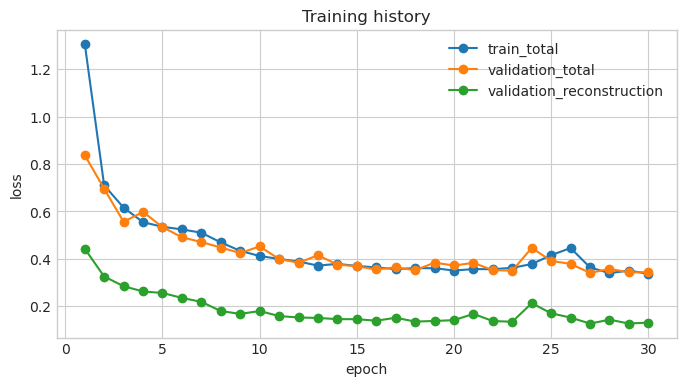

In [8]:
# Train one useful default model. Use run_ablation_suite(loaders) for the full ablation matrix.
default_spec = make_ablation_configs()["A4_full"]
default_train_config = replace(TrainConfig(), graph_mode=default_spec.graph_mode)
training_result = fit_model(loaders, default_spec.model, default_train_config)

display(training_result["history"])
print("Best epoch:", training_result["best_epoch"])
print("Stationary held-out test metrics:")
display(pd.Series(training_result["test_metrics"]))

training_result["history"].plot(
    x="epoch", y=["train_total", "validation_total", "validation_reconstruction"],
    marker="o", figsize=(8, 4), title="Training history"
)
plt.ylabel("loss")
plt.show()


## 3. Evaluate dense crystals and liquids from both melting runs

O(3) audit:


z_structure_invariance_max_abs         0.000001
z_vector_equivariance_max_abs          0.000160
z_tensor_equivariance_max_abs          0.000033
reconstruction_equivariance_max_abs    0.000173
dtype: float64

Permutation audit:


z_structure_permutation_invariance_max_abs    1.192093e-07
reconstruction_set_difference_chamfer         5.835888e-13
dtype: float64

Invariant-latent standard deviations: [0.0229 0.0262 0.0284 0.0333]
Invariant-latent effective rank: 1.01 / 4


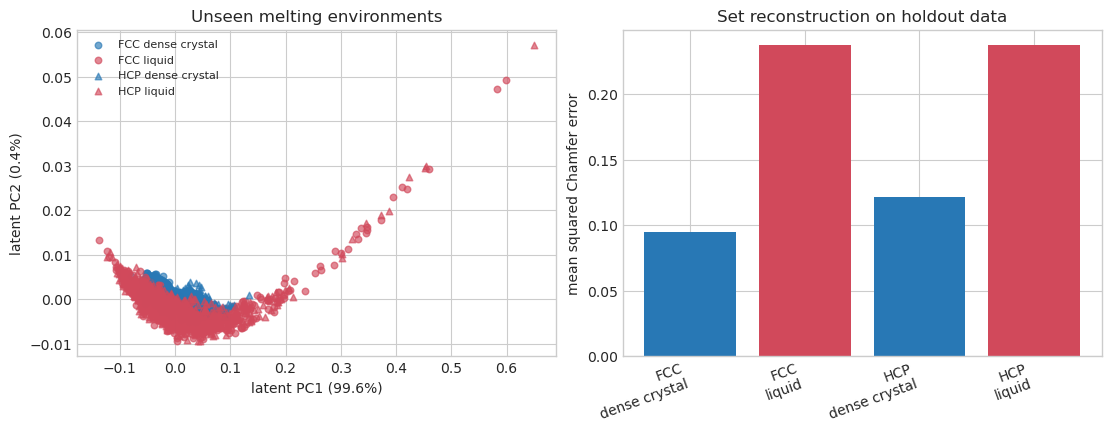

reconstruction_error  noise_stability
phase_origin regime                                              
fcc          dense_crystal              0.094975         0.000017
             liquid                     0.237418         0.000378
hcp          dense_crystal              0.121127         0.000027
             liquid                     0.237295         0.000249

In [9]:
unseen_results = evaluate_on_unseen_MD(
    training_result["model"],
    melting_evaluation,
    graph_mode=training_result["train_config"].graph_mode,
)

print("O(3) audit:")
display(pd.Series(unseen_results["symmetry"]))
print("Permutation audit:")
display(pd.Series(unseen_results["permutation"]))
latent_summary = inspect_latent(unseen_results)


## Reading the result

- FCC/HCP stationary files supply training, validation, and internal test data; the melting runs are external holdouts.
- `dense_crystal` frames are selected at least 50,000 steps before the detected transition and from the upper density quartile of still-ordered states.
- `liquid` frames are selected only after the full 50,000-step post-transition analysis window and from the low-$Q_6$ tail. The immediate classifier-collapse frames are intentionally excluded.
- Low symmetry-audit errors confirm the architectural guarantees numerically. They do not by themselves show that the latent is scientifically useful; inspect phase/regime separation, reconstruction, stability, and repeat across seeds/ablations.
- The equivariant decoder can be underdetermined for exact high-symmetry crystals because a unique vector frame does not exist. Noisy MD environments usually break that degeneracy; invariant-distance reconstruction is the appropriate ablation if it remains limiting.